# GLD Quantitative Trading Strategy Analysis

This notebook provides an interactive analysis of the GLD trading strategy.

## Table of Contents
1. Setup & Data Loading
2. Exploratory Data Analysis
3. Indicator Analysis
4. Signal Generation
5. Backtest Results
6. Performance Metrics


In [1]:
# Setup: Add src to path and import modules
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Import our strategy modules
from data import load_gld_data, calculate_price_returns, get_data_summary, print_data_summary
from indicators import calculate_all_indicators
from signals import generate_signals
from backtest import run_backtest
from metrics import calculate_all_metrics, print_metrics_report

# Plotting settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("All modules loaded successfully!")


All modules loaded successfully!


In [2]:
# Load configuration
with open('../configs/default.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"  Trend lookback: {config['trend']['lookback_days']} days")
print(f"  Volatility lookback: {config['volatility']['lookback_days']} days")
print(f"  RSI period: {config['mean_reversion']['rsi_period']} days")
print(f"  Leverage range: [{config['exposure']['max_short']}, {config['exposure']['max_long']}]")


Configuration loaded:
  Trend lookback: 60 days
  Volatility lookback: 20 days
  RSI period: 14 days
  Leverage range: [-1.0, 1.5]


In [3]:
# Load and preprocess GLD data
df = load_gld_data('../data/processed/gld.csv')
df = calculate_price_returns(df)

# Print summary
summary = get_data_summary(df)
print_data_summary(summary)


Loaded 2264 rows from ../data/processed/gld.csv
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Change', '%Change', 'Volume']
Date range: 1/3/11 to 12/31/19
After sorting - Date range: 2011-01-03 00:00:00 to 2019-12-31 00:00:00

log_return    1
dtype: int64

Final dataset shape: (2264, 7)
Date range: 2011-01-03 00:00:00 to 2019-12-31 00:00:00
Number of trading days: 2264

GLD DATA SUMMARY

📅 DATE RANGE:
   Start: 2011-01-03
   End:   2019-12-31
   Trading Days: 2264

💰 PRICE:
   Start Price:  $138.00
   End Price:    $142.90
   Min Price:    $100.50
   Max Price:    $184.59
   Total Return: 3.55%

📊 RETURNS:
   Mean Daily Return:     0.0015%
   Daily Volatility:      0.9707%
   Annualized Return:     0.39%
   Annualized Volatility: 15.41%
   Worst Day:             -9.19%
   Best Day:              4.80%

✅ DATA QUALITY:
   Missing Values:    4
   Zero Volume Days:  0


In [4]:
# Run the complete strategy pipeline
# 1. Calculate indicators
df = calculate_all_indicators(df, 
    trend_lookback=config['trend']['lookback_days'],
    vol_lookback=config['volatility']['lookback_days'],
    rsi_period=config['mean_reversion']['rsi_period'])

# 2. Generate signals
df = generate_signals(df,
    max_long=config['exposure']['max_long'],
    max_short=config['exposure']['max_short'])

# 3. Run backtest
results = run_backtest(df,
    transaction_cost=config['backtest']['transaction_cost'],
    initial_capital=config['backtest']['initial_capital'],
    start_date=config['backtest']['start_date'],
    end_date=config['backtest']['end_date'])

# 4. Calculate metrics
metrics = calculate_all_metrics(results)
print_metrics_report(metrics)


Calculating indicators...
  - Rolling slope (lookback=60)
  - Slope z-score (lookback=252)
  - Fast slope (lookback=20)
  - Slow slope (lookback=120)
  - Fast slope z-score (lookback=252)
  - Slow slope z-score (lookback=252)
  - Realized volatility (lookback=20)
  - Volatility percentile (lookback=252)
  - Volatility trend (lookback=10)
  - RSI (period=14)
  - Returns z-score (lookback=20)
  - Ulcer Index (lookback=14)

Indicator coverage (non-null values):
  - slope: 2205/2264 (97.4%)
  - slope_zscore: 2080/2264 (91.9%)
  - slope_fast: 2245/2264 (99.2%)
  - slope_slow: 2145/2264 (94.7%)
  - slope_fast_zscore: 2120/2264 (93.6%)
  - slope_slow_zscore: 2020/2264 (89.2%)
  - volatility: 2244/2264 (99.1%)
  - vol_percentile: 2119/2264 (93.6%)
  - vol_trend: 2235/2264 (98.7%)
  - rsi: 2263/2264 (100.0%)
  - returns_zscore: 2254/2264 (99.6%)
  - ulcer_index: 2238/2264 (98.9%)

Generating trading signals...
  - Generating base trend signal from FAST slope z-score
  - Applying slow-trend regi

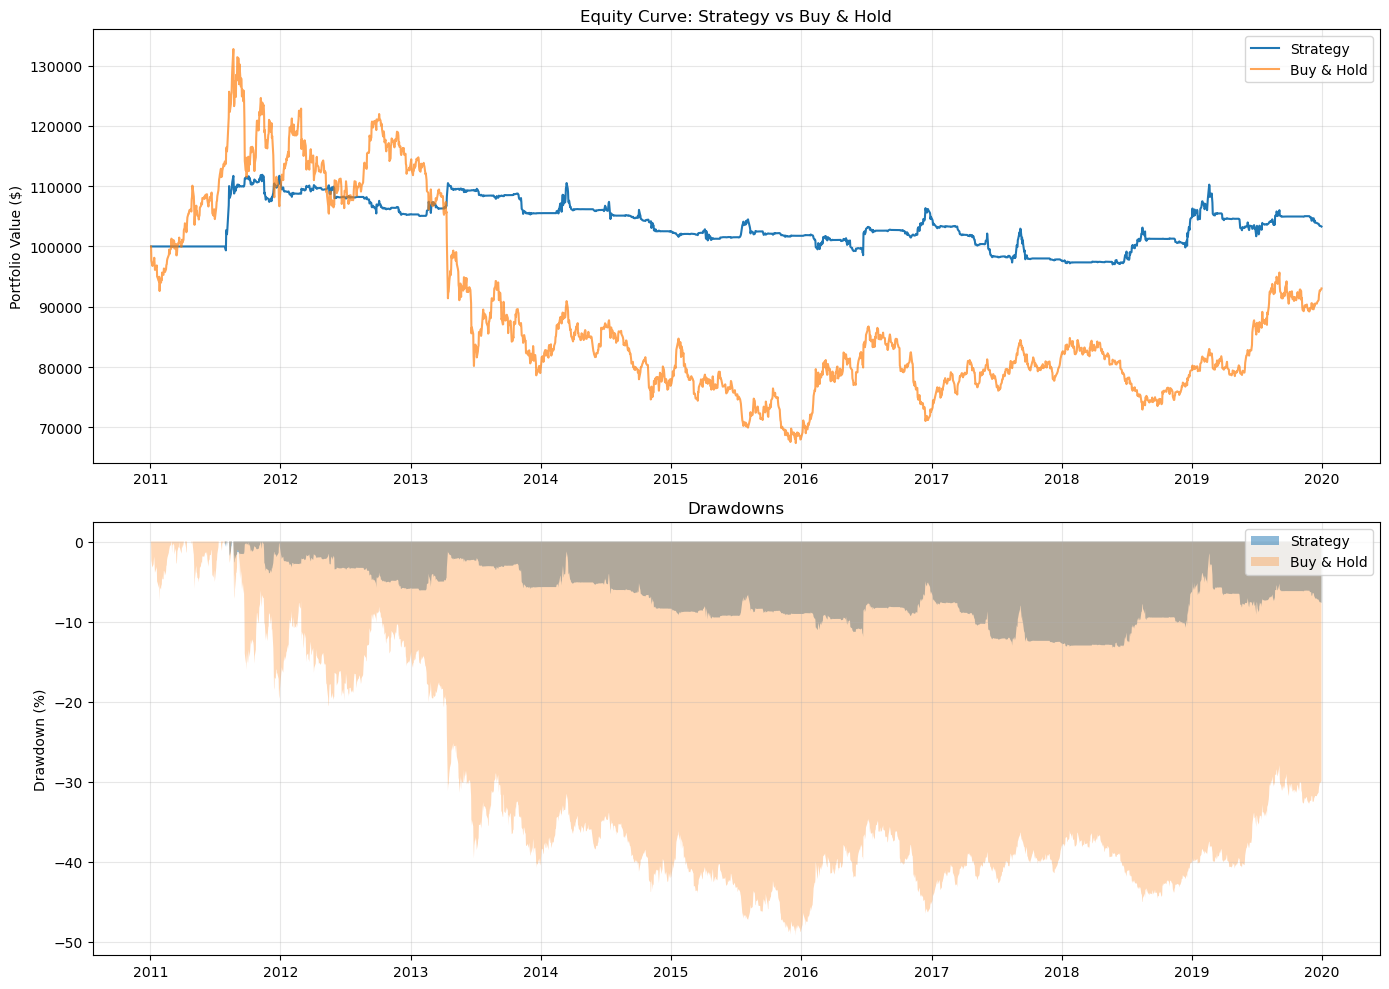


🎯 CALMAR RATIO: 0.03 (Target: ≥ 2.0)
⏱️  TIME IN MARKET: 50.2% (Target: ≥ 20%)


In [5]:
# Visualize Results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plot_df = results['data'].dropna(subset=['equity'])

# Equity Curve
ax1 = axes[0]
ax1.plot(plot_df.index, plot_df['equity'], label='Strategy', linewidth=1.5)
ax1.plot(plot_df.index, plot_df['bh_equity'], label='Buy & Hold', alpha=0.7)
ax1.set_title('Equity Curve: Strategy vs Buy & Hold')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdowns
ax2 = axes[1]
ax2.fill_between(plot_df.index, plot_df['drawdown'] * 100, 0, label='Strategy', alpha=0.5)
ax2.fill_between(plot_df.index, plot_df['bh_drawdown'] * 100, 0, label='Buy & Hold', alpha=0.3)
ax2.set_title('Drawdowns')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 CALMAR RATIO: {metrics['strategy']['calmar_ratio']:.2f} (Target: ≥ 2.0)")
print(f"⏱️  TIME IN MARKET: {metrics['trading']['time_in_market']:.1f}% (Target: ≥ 20%)")
